# Comparison of TARNet, CFRNet, ATARNet, DragonNet, and Logistic Regression

## Experiment definition

- Treatment \(T=1\): `Womens E-Mail` or `Mens E-Mail`
- Control \(T=0\): `No E-Mail`
- Outcome \(Y\): `visit`
- Test split: 20%, stratified by treatment, random state 42
- Validation split: 20% of the training portion, stratified by treatment, random state 42


# Boiler Plate

In [1]:
import copy
import json
import math
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Iterable, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset


@dataclass
class Config:
    data_path: str | None = None
    output_directory: str = (
        "all_model_comparison_outputs"
    )

    # Shared experiment split. These remain identical for every model.
    test_size: float = 0.20
    validation_size_within_train: float = 0.20
    split_seed: int = 42

    # Seeds used in the supplied notebooks.
    tarnet_seed: int = 123
    cfrnet_seed: int = 123
    atarnet_seed: int = 123
    dragonnet_seed: int = 42

    # --------------------------------------------------------------
    # TARNet parameters from 03_deep_learning_binary_tarnet.ipynb
    # --------------------------------------------------------------
    tarnet_batch_size: int = 256
    tarnet_number_of_epochs: int = 20
    tarnet_learning_rate: float = 5e-4
    tarnet_l2_strength: float = 1e-4
    tarnet_embedding_dim: int = 4
    tarnet_shared_width: int = 128
    tarnet_representation_dim: int = 64
    tarnet_head_width: int = 32
    tarnet_dropout: float = 0.15

    # --------------------------------------------------------------
    # CFRNet parameters from 03_deep_learning_cfr_net.ipynb
    # --------------------------------------------------------------
    cfrnet_batch_size: int = 256
    cfrnet_number_of_epochs: int = 20
    cfrnet_learning_rate: float = 5e-4
    cfrnet_l2_strength: float = 1e-4
    cfrnet_embedding_dim: int = 4
    cfrnet_shared_width: int = 128
    cfrnet_representation_dim: int = 64
    cfrnet_head_width: int = 32
    cfrnet_dropout: float = 0.15
    cfrnet_imbalance_weight: float = 1.0

    # --------------------------------------------------------------
    # ATARNet parameters from
    # 03_deep_learning_specific_atarnet.ipynb
    # --------------------------------------------------------------
    atarnet_batch_size: int = 256
    atarnet_number_of_epochs: int = 20
    atarnet_learning_rate: float = 5e-4
    atarnet_token_dim: int = 16
    atarnet_num_heads: int = 4
    atarnet_transformer_hidden_dim: int = 32
    atarnet_pooling_hidden_dim: int = 16
    atarnet_outcome_hidden_dim: int = 16

    # --------------------------------------------------------------
    # DragonNet parameters from
    # dragonnet_hillstrom_atarnet_aligned_comparison.ipynb
    # --------------------------------------------------------------
    dragonnet_batch_size: int = 512
    dragonnet_max_epochs: int = 150
    dragonnet_patience: int = 15
    dragonnet_learning_rate: float = 1e-3
    dragonnet_weight_decay: float = 1e-4
    dragonnet_gradient_clip_norm: float = 5.0
    dragonnet_representation_hidden_dim: int = 128
    dragonnet_representation_dim: int = 64
    dragonnet_outcome_head_hidden_dim: int = 32
    dragonnet_dropout: float = 0.10
    dragonnet_propensity_loss_weight: float = 1.0
    dragonnet_targeted_regularization_weight: float = 0.10

    bootstrap_iterations: int = 300
    targeting_fractions: tuple = (
        0.05, 0.10, 0.20, 0.30, 0.50, 1.00
    )


CONFIG = Config()


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(CONFIG.tarnet_seed)

torch.set_num_threads(1)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print(json.dumps(asdict(CONFIG), indent=2))


Device: cpu
{
  "data_path": null,
  "output_directory": "all_model_comparison_outputs",
  "test_size": 0.2,
  "validation_size_within_train": 0.2,
  "split_seed": 42,
  "tarnet_seed": 123,
  "cfrnet_seed": 123,
  "atarnet_seed": 123,
  "dragonnet_seed": 42,
  "tarnet_batch_size": 256,
  "tarnet_number_of_epochs": 20,
  "tarnet_learning_rate": 0.0005,
  "tarnet_l2_strength": 0.0001,
  "tarnet_embedding_dim": 4,
  "tarnet_shared_width": 128,
  "tarnet_representation_dim": 64,
  "tarnet_head_width": 32,
  "tarnet_dropout": 0.15,
  "cfrnet_batch_size": 256,
  "cfrnet_number_of_epochs": 20,
  "cfrnet_learning_rate": 0.0005,
  "cfrnet_l2_strength": 0.0001,
  "cfrnet_embedding_dim": 4,
  "cfrnet_shared_width": 128,
  "cfrnet_representation_dim": 64,
  "cfrnet_head_width": 32,
  "cfrnet_dropout": 0.15,
  "cfrnet_imbalance_weight": 1.0,
  "atarnet_batch_size": 256,
  "atarnet_number_of_epochs": 20,
  "atarnet_learning_rate": 0.0005,
  "atarnet_token_dim": 16,
  "atarnet_num_heads": 4,
  "atarn

# Load Dataset

In [2]:
# DATA_PATH = "/Users/davinci/Projects/dragon_net/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"

DATA_PATH = Path("../data/raw/hillstrom_email.csv")
df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Raw shape:", df.shape)
display(df.head())

Loaded: ../data/raw/hillstrom_email.csv
Raw shape: (64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


# Shared Treatment, outcome & features

In [3]:
numerical_columns = [
    "recency",
    "history",
    "mens",
    "womens",
]

categorical_columns = [
    "history_segment",
    "zip_code",
    "newbie",
    "channel",
]

treatment_column = "treatment"
outcome_column = "visit"

df = df.copy()
df["original_row_index"] = df.index.astype(int)

df[treatment_column] = (
    df["segment"] != "No E-Mail"
).astype(int)

required_columns = (
    numerical_columns
    + categorical_columns
    + [treatment_column, outcome_column]
)

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

display(
    df.groupby(treatment_column)[outcome_column]
    .agg(customers="size", visit_rate="mean")
    .rename(index={0: "No E-Mail", 1: "Any E-Mail"})
)


,customers,visit_rate
treatment,,
No E-Mail,21306,0.106167
Any E-Mail,42694,0.167049


# Create shared train/test & validation dataset

In [4]:
all_indices = np.arange(len(df))

train_validation_indices, test_indices = train_test_split(
    all_indices,
    test_size=CONFIG.test_size,
    random_state=CONFIG.split_seed,
    stratify=df[treatment_column],
)

train_indices, validation_indices = train_test_split(
    train_validation_indices,
    test_size=CONFIG.validation_size_within_train,
    random_state=CONFIG.split_seed,
    stratify=df.iloc[train_validation_indices][treatment_column],
)

train_df = df.iloc[train_indices].copy()
validation_df = df.iloc[validation_indices].copy()
test_df = df.iloc[test_indices].copy()

split_summary = []

for name, frame in [
    ("train", train_df),
    ("validation", validation_df),
    ("test", test_df),
]:
    summary = (
        frame.groupby(treatment_column)[outcome_column]
        .agg(customers="size", visit_rate="mean")
        .reset_index()
    )
    summary["split"] = name
    summary["group"] = summary[treatment_column].map({
        0: "No E-Mail",
        1: "Any E-Mail",
    })
    split_summary.append(summary)

display(pd.concat(split_summary, ignore_index=True))

assert set(train_indices).isdisjoint(validation_indices)
assert set(train_indices).isdisjoint(test_indices)
assert set(validation_indices).isdisjoint(test_indices)

print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))


,treatment,customers,visit_rate,split,group
0,0,13636,0.105163,train,No E-Mail
1,1,27324,0.164873,train,Any E-Mail
2,0,3409,0.108536,validation,No E-Mail
3,1,6831,0.175084,validation,Any E-Mail
4,0,4261,0.107487,test,No E-Mail
5,1,8539,0.167584,test,Any E-Mail


Train: 40960
Validation: 10240
Test: 12800


# Preprocessing

In [5]:
scaler = StandardScaler()
scaler.fit(train_df[numerical_columns])

category_mappings = {}

for column in categorical_columns:
    categories = sorted(
        train_df[column].dropna().unique().tolist()
    )

    category_mappings[column] = {
        category: index
        for index, category in enumerate(categories)
    }

category_cardinalities = [
    len(category_mappings[column])
    for column in categorical_columns
]


def make_tensors(frame: pd.DataFrame) -> TensorDataset:
    numeric = scaler.transform(
        frame[numerical_columns]
    ).astype(np.float32)

    categorical_parts = []

    for column in categorical_columns:
        mapped = frame[column].map(
            category_mappings[column]
        )

        if mapped.isna().any():
            unseen = (
                frame.loc[mapped.isna(), column]
                .drop_duplicates()
                .tolist()
            )

        categorical_parts.append(
            mapped.to_numpy(dtype=np.int64)
        )

    categorical = np.column_stack(categorical_parts)
    treatment = frame[treatment_column].to_numpy(dtype=np.int64)
    outcome = frame[outcome_column].to_numpy(dtype=np.float32)

    return TensorDataset(
        torch.tensor(numeric, dtype=torch.float32),
        torch.tensor(categorical, dtype=torch.long),
        torch.tensor(treatment, dtype=torch.long),
        torch.tensor(outcome, dtype=torch.float32),
    )


train_dataset = make_tensors(train_df)
validation_dataset = make_tensors(validation_df)
test_dataset = make_tensors(test_df)

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)
print("Category cardinalities:", category_cardinalities)

feature_columns = numerical_columns + categorical_columns

one_hot_encoder_kwargs = {
    "handle_unknown": "ignore",
}

if "sparse_output" in OneHotEncoder.__init__.__code__.co_varnames:
    one_hot_encoder_kwargs["sparse_output"] = False
else:
    one_hot_encoder_kwargs["sparse"] = False

logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        (
            "cat",
            OneHotEncoder(**one_hot_encoder_kwargs),
            categorical_columns,
        ),
    ]
)

X_train_logistic = logistic_preprocessor.fit_transform(
    train_df[feature_columns]
)
X_test_logistic = logistic_preprocessor.transform(
    test_df[feature_columns]
)

train_treatment_array = train_df[treatment_column].to_numpy()
train_outcome_array = train_df[outcome_column].to_numpy()


Numerical columns: ['recency', 'history', 'mens', 'womens']
Categorical columns: ['history_segment', 'zip_code', 'newbie', 'channel']
Category cardinalities: [7, 3, 2, 3]


# Reproducible data loaders

In [6]:
def make_loader(
    dataset: TensorDataset,
    shuffle: bool,
    seed: int,
    batch_size: int,
) -> DataLoader:
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        num_workers=0,
    )


def model_training_config(
    model_name: str,
) -> dict:
    configurations = {
        "TARNet": {
            "seed": CONFIG.tarnet_seed,
            "batch_size": CONFIG.tarnet_batch_size,
            "epochs": CONFIG.tarnet_number_of_epochs,
            "learning_rate": CONFIG.tarnet_learning_rate,
            "optimizer": "Adam",
            "weight_decay": 0.0,
            "patience": None,
            "gradient_clip_norm": None,
        },
        "CFRNet": {
            "seed": CONFIG.cfrnet_seed,
            "batch_size": CONFIG.cfrnet_batch_size,
            "epochs": CONFIG.cfrnet_number_of_epochs,
            "learning_rate": CONFIG.cfrnet_learning_rate,
            "optimizer": "Adam",
            "weight_decay": 0.0,
            "patience": None,
            "gradient_clip_norm": None,
        },
        "ATARNet": {
            "seed": CONFIG.atarnet_seed,
            "batch_size": CONFIG.atarnet_batch_size,
            "epochs": CONFIG.atarnet_number_of_epochs,
            "learning_rate": CONFIG.atarnet_learning_rate,
            "optimizer": "Adam",
            "weight_decay": 0.0,
            "patience": None,
            "gradient_clip_norm": None,
        },
        "DragonNet": {
            "seed": CONFIG.dragonnet_seed,
            "batch_size": CONFIG.dragonnet_batch_size,
            "epochs": CONFIG.dragonnet_max_epochs,
            "learning_rate": CONFIG.dragonnet_learning_rate,
            "optimizer": "AdamW",
            "weight_decay": CONFIG.dragonnet_weight_decay,
            "patience": CONFIG.dragonnet_patience,
            "gradient_clip_norm": (
                CONFIG.dragonnet_gradient_clip_norm
            ),
        },
    }

    if model_name not in configurations:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    return configurations[model_name]


def get_loaders(model_name: str):
    settings = model_training_config(model_name)

    return (
        make_loader(
            train_dataset,
            True,
            settings["seed"],
            settings["batch_size"],
        ),
        make_loader(
            validation_dataset,
            False,
            settings["seed"],
            settings["batch_size"],
        ),
        make_loader(
            test_dataset,
            False,
            settings["seed"],
            settings["batch_size"],
        ),
    )


treatment_prevalence = (
    train_dataset.tensors[2]
    .float()
    .mean()
    .to(device)
)

print(
    "Training treatment prevalence:",
    float(treatment_prevalence),
)

display(
    pd.DataFrame({
        model_name: model_training_config(model_name)
        for model_name in [
            "TARNet",
            "CFRNet",
            "ATARNet",
            "DragonNet",
        ]
    }).T
)


Training treatment prevalence: 0.6670898199081421


,seed,batch_size,epochs,learning_rate,optimizer,weight_decay,patience,gradient_clip_norm
TARNet,123,256,20,0.0005,Adam,0.0,None,None
CFRNet,123,256,20,0.0005,Adam,0.0,None,None
ATARNet,123,256,20,0.0005,Adam,0.0,None,None
DragonNet,42,512,150,0.001,AdamW,0.0001,15,5.0


# Individual model Architectures

## Shared Tarnet

In [7]:
class FeatureEncoder(nn.Module):
    def __init__(
        self,
        num_numeric: int,
        category_sizes: list[int],
        embedding_dim: int = 4,
    ):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_dim)
            for size in category_sizes
        ])

        self.output_dim = (
            num_numeric
            + len(category_sizes) * embedding_dim
        )

    def forward(
        self,
        numeric: torch.Tensor,
        categorical: torch.Tensor,
    ) -> torch.Tensor:
        embedded = [
            embedding(categorical[:, index])
            for index, embedding in enumerate(self.embeddings)
        ]

        return torch.cat([numeric, *embedded], dim=1)


class ResidualBlock(nn.Module):
    def __init__(self, width: int, dropout: float):
        super().__init__()

        self.block = nn.Sequential(
            nn.LayerNorm(width),
            nn.Linear(width, width * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(width * 2, width),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return inputs + self.block(inputs)


class OutcomeHead(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        dropout: float,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(
        self,
        representation: torch.Tensor,
    ) -> torch.Tensor:
        return self.network(representation)


## Binary TARNet

In [8]:
class TARNet(nn.Module):
    def __init__(
        self,
        num_numeric: int,
        category_sizes: list[int],
        embedding_dim: int,
        shared_width: int,
        representation_dim: int,
        head_width: int,
        dropout: float,
    ):
        super().__init__()

        self.encoder = FeatureEncoder(
            num_numeric=num_numeric,
            category_sizes=category_sizes,
            embedding_dim=embedding_dim,
        )

        self.shared_network = nn.Sequential(
            nn.Linear(
                self.encoder.output_dim,
                shared_width,
            ),
            nn.GELU(),
            ResidualBlock(shared_width, dropout),
            ResidualBlock(shared_width, dropout),
            nn.LayerNorm(shared_width),
            nn.Linear(
                shared_width,
                representation_dim,
            ),
            nn.GELU(),
        )

        self.outcome_heads = nn.ModuleList([
            OutcomeHead(
                representation_dim,
                head_width,
                dropout,
            )
            for _ in range(2)
        ])

    def forward(self, numeric, categorical):
        features = self.encoder(numeric, categorical)
        representation = self.shared_network(features)

        logits = [
            head(representation)
            for head in self.outcome_heads
        ]

        return torch.cat(logits, dim=1)


def weighted_tarnet_loss(
    all_logits,
    treatment,
    outcome,
    prevalence,
):
    factual_logits = all_logits.gather(
        1,
        treatment.unsqueeze(1),
    ).squeeze(1)

    sample_loss = nn.functional.binary_cross_entropy_with_logits(
        factual_logits,
        outcome,
        reduction="none",
    )

    treatment_float = treatment.float()

    sample_weight = (
        treatment_float / (2 * prevalence)
        + (1 - treatment_float)
        / (2 * (1 - prevalence))
    )

    return (sample_weight * sample_loss).mean()


def tarnet_head_l2(model):
    return sum(
        parameter.square().sum()
        for head in model.outcome_heads
        for name, parameter in head.named_parameters()
        if "weight" in name
    )


## CFRNet

In [9]:
def normalize_representation(
    representation: torch.Tensor,
    eps: float = 1e-8,
) -> torch.Tensor:
    norm = (
        representation.norm(
            p=2,
            dim=1,
            keepdim=True,
        )
        .clamp_min(eps)
    )

    return representation / norm


class CFRNet(nn.Module):
    def __init__(
        self,
        num_numeric: int,
        category_sizes: list[int],
        embedding_dim: int,
        shared_width: int,
        representation_dim: int,
        head_width: int,
        dropout: float,
    ):
        super().__init__()

        self.encoder = FeatureEncoder(
            num_numeric=num_numeric,
            category_sizes=category_sizes,
            embedding_dim=embedding_dim,
        )

        self.shared_network = nn.Sequential(
            nn.Linear(
                self.encoder.output_dim,
                shared_width,
            ),
            nn.GELU(),
            ResidualBlock(shared_width, dropout),
            ResidualBlock(shared_width, dropout),
            nn.LayerNorm(shared_width),
            nn.Linear(
                shared_width,
                representation_dim,
            ),
            nn.GELU(),
        )

        self.control_head = OutcomeHead(
            representation_dim,
            head_width,
            dropout,
        )

        self.treatment_head = OutcomeHead(
            representation_dim,
            head_width,
            dropout,
        )

    def forward(self, numeric, categorical):
        features = self.encoder(numeric, categorical)
        representation = self.shared_network(features)
        representation = normalize_representation(
            representation
        )

        return {
            "control_logit": self.control_head(
                representation
            ).squeeze(1),
            "treatment_logit": self.treatment_head(
                representation
            ).squeeze(1),
            "representation": representation,
        }


def linear_mmd_penalty(
    control_representation,
    treatment_representation,
):
    if (
        len(control_representation) < 2
        or len(treatment_representation) < 2
    ):
        return control_representation.new_tensor(0.0)

    return torch.sum(
        (
            control_representation.mean(dim=0)
            - treatment_representation.mean(dim=0)
        ) ** 2
    )


def cfr_factual_loss(
    control_logit,
    treatment_logit,
    treatment,
    outcome,
    prevalence,
):
    control_loss = (
        nn.functional.binary_cross_entropy_with_logits(
            control_logit,
            outcome,
            reduction="none",
        )
    )

    treatment_loss = (
        nn.functional.binary_cross_entropy_with_logits(
            treatment_logit,
            outcome,
            reduction="none",
        )
    )

    treatment_float = treatment.float()

    sample_loss = (
        (1 - treatment_float) * control_loss
        + treatment_float * treatment_loss
    )

    sample_weight = (
        treatment_float / (2 * prevalence)
        + (1 - treatment_float)
        / (2 * (1 - prevalence))
    )

    return (sample_weight * sample_loss).mean()


def cfr_head_l2(model):
    return sum(
        parameter.square().sum()
        for head in [
            model.control_head,
            model.treatment_head,
        ]
        for name, parameter in head.named_parameters()
        if "weight" in name
    )


## Specific ATARNet / Transformer TARNet


In [10]:
class FeatureTokenizer(nn.Module):
    def __init__(
        self,
        num_features: int,
        category_sizes: list[int],
        token_dim: int,
    ):
        super().__init__()

        self.num_weights = nn.Parameter(
            torch.empty(num_features, token_dim)
        )
        self.num_biases = nn.Parameter(
            torch.empty(num_features, token_dim)
        )

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(size, token_dim)
            for size in category_sizes
        ])

        nn.init.xavier_uniform_(self.num_weights)
        nn.init.zeros_(self.num_biases)

        for embedding in self.cat_embeddings:
            nn.init.xavier_uniform_(embedding.weight)

    def forward(self, numeric, categorical):
        numerical_tokens = (
            numeric.unsqueeze(-1) * self.num_weights
            + self.num_biases
        )

        categorical_tokens = torch.stack([
            embedding(categorical[:, index])
            for index, embedding
            in enumerate(self.cat_embeddings)
        ], dim=1)

        return torch.cat(
            [numerical_tokens, categorical_tokens],
            dim=1,
        )


class TransformerBlock(nn.Module):
    def __init__(
        self,
        token_dim: int,
        num_heads: int,
        hidden_dim: int,
    ):
        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=token_dim,
            num_heads=num_heads,
            batch_first=True,
        )

        self.norm1 = nn.LayerNorm(token_dim)
        self.norm2 = nn.LayerNorm(token_dim)

        self.feed_forward = nn.Sequential(
            nn.Linear(token_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, token_dim),
        )

    def forward(self, tokens):
        attention_output, _ = self.attention(
            tokens,
            tokens,
            tokens,
            need_weights=False,
        )

        normalized = self.norm1(
            tokens + attention_output
        )

        return self.norm2(
            normalized + self.feed_forward(normalized)
        )


class AttentionPooling(nn.Module):
    def __init__(
        self,
        token_dim: int,
        hidden_dim: int,
    ):
        super().__init__()

        self.score = nn.Sequential(
            nn.Linear(token_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, tokens):
        weights = torch.softmax(
            self.score(tokens),
            dim=1,
        )

        representation = (
            tokens * weights
        ).sum(dim=1)

        return representation


class ATARNetOutcomeHead(nn.Module):
    def __init__(
        self,
        token_dim: int,
        pooling_hidden_dim: int,
        outcome_hidden_dim: int,
    ):
        super().__init__()

        self.pooling = AttentionPooling(
            token_dim,
            pooling_hidden_dim,
        )

        self.network = nn.Sequential(
            nn.Linear(token_dim, outcome_hidden_dim),
            nn.ReLU(),
            nn.Linear(outcome_hidden_dim, 1),
        )

    def forward(self, tokens):
        representation = self.pooling(tokens)
        return self.network(representation).squeeze(1)


class ATARNet(nn.Module):
    def __init__(
        self,
        num_features: int,
        category_sizes: list[int],
        token_dim: int,
        num_heads: int,
        transformer_hidden_dim: int,
        pooling_hidden_dim: int,
        outcome_hidden_dim: int,
    ):
        super().__init__()

        self.tokenizer = FeatureTokenizer(
            num_features,
            category_sizes,
            token_dim,
        )

        self.transformer = TransformerBlock(
            token_dim,
            num_heads,
            transformer_hidden_dim,
        )

        self.control_head = ATARNetOutcomeHead(
            token_dim,
            pooling_hidden_dim,
            outcome_hidden_dim,
        )

        self.treatment_head = ATARNetOutcomeHead(
            token_dim,
            pooling_hidden_dim,
            outcome_hidden_dim,
        )

    def forward(self, numeric, categorical):
        tokens = self.tokenizer(numeric, categorical)
        contextualized = self.transformer(tokens)

        return {
            "control_logit": self.control_head(
                contextualized
            ),
            "treatment_logit": self.treatment_head(
                contextualized
            ),
        }


def atarnet_factual_loss(
    control_logit,
    treatment_logit,
    treatment,
    outcome,
    prevalence,
):
    treatment_float = treatment.float()

    control_loss = (
        nn.functional.binary_cross_entropy_with_logits(
            control_logit,
            outcome,
            reduction="none",
        )
    )

    treatment_loss = (
        nn.functional.binary_cross_entropy_with_logits(
            treatment_logit,
            outcome,
            reduction="none",
        )
    )

    sample_loss = (
        (1 - treatment_float) * control_loss
        + treatment_float * treatment_loss
    )

    sample_weight = (
        treatment_float / (2 * prevalence)
        + (1 - treatment_float)
        / (2 * (1 - prevalence))
    )

    return (sample_weight * sample_loss).mean()


## DragonNet

In [11]:
class DragonNet(nn.Module):
    def __init__(
        self,
        num_numeric: int,
        category_sizes: list[int],
        embedding_dim: int,
        representation_hidden_dim: int,
        representation_dim: int,
        outcome_head_hidden_dim: int,
        dropout: float,
    ):
        super().__init__()

        self.encoder = FeatureEncoder(
            num_numeric=num_numeric,
            category_sizes=category_sizes,
            embedding_dim=embedding_dim,
        )

        self.shared_network = nn.Sequential(
            nn.Linear(
                self.encoder.output_dim,
                representation_hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                representation_hidden_dim,
                representation_hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                representation_hidden_dim,
                representation_dim,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.control_head = OutcomeHead(
            representation_dim,
            outcome_head_hidden_dim,
            dropout,
        )

        self.treatment_head = OutcomeHead(
            representation_dim,
            outcome_head_hidden_dim,
            dropout,
        )

        self.propensity_head = nn.Sequential(
            nn.Linear(
                representation_dim,
                outcome_head_hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                outcome_head_hidden_dim,
                1,
            ),
        )

        # Trainable targeted-regularization parameter.
        self.epsilon = nn.Parameter(
            torch.zeros(1)
        )

    def forward(self, numeric, categorical):
        features = self.encoder(numeric, categorical)
        representation = self.shared_network(features)

        return {
            "control_logit": self.control_head(
                representation
            ).squeeze(1),
            "treatment_logit": self.treatment_head(
                representation
            ).squeeze(1),
            "propensity_logit": self.propensity_head(
                representation
            ).squeeze(1),
            "epsilon": self.epsilon,
        }


def dragonnet_loss(
    outputs,
    treatment,
    outcome,
    propensity_loss_weight,
    targeted_regularization_weight,
):
    treatment_float = treatment.float()

    control_probability = torch.sigmoid(
        outputs["control_logit"]
    )

    treatment_probability = torch.sigmoid(
        outputs["treatment_logit"]
    )

    factual_probability = torch.where(
        treatment == 1,
        treatment_probability,
        control_probability,
    )

    factual_loss = (
        nn.functional.binary_cross_entropy(
            factual_probability,
            outcome,
        )
    )

    propensity_loss = (
        nn.functional.binary_cross_entropy_with_logits(
            outputs["propensity_logit"],
            treatment_float,
        )
    )

    propensity = torch.sigmoid(
        outputs["propensity_logit"]
    ).clamp(1e-3, 1 - 1e-3)

    clever_covariate = (
        treatment_float / propensity
        - (1 - treatment_float) / (1 - propensity)
    )

    targeted_prediction = (
        factual_probability
        + outputs["epsilon"] * clever_covariate
    ).clamp(1e-5, 1 - 1e-5)

    targeted_loss = (
        nn.functional.binary_cross_entropy(
            targeted_prediction,
            outcome,
        )
    )

    total_loss = (
        factual_loss
        + propensity_loss_weight * propensity_loss
        + targeted_regularization_weight * targeted_loss
    )

    return {
        "total_loss": total_loss,
        "factual_loss": factual_loss,
        "propensity_loss": propensity_loss,
        "targeted_loss": targeted_loss,
    }


## Training & Validation Funcns

In [12]:
def factual_validation_loss(
    model_name: str,
    model: nn.Module,
    loader: DataLoader,
) -> float:
    model.eval()
    total_loss = 0.0
    total_rows = 0

    with torch.no_grad():
        for numeric, categorical, treatment, outcome in loader:
            numeric = numeric.to(device)
            categorical = categorical.to(device)
            treatment = treatment.to(device)
            outcome = outcome.to(device)

            if model_name == "TARNet":
                logits = model(numeric, categorical)
                factual_logits = logits.gather(
                    1,
                    treatment.unsqueeze(1),
                ).squeeze(1)

            else:
                outputs = model(numeric, categorical)
                factual_logits = torch.where(
                    treatment == 1,
                    outputs["treatment_logit"],
                    outputs["control_logit"],
                )

            loss = (
                nn.functional.binary_cross_entropy_with_logits(
                    factual_logits,
                    outcome,
                    reduction="sum",
                )
            )

            total_loss += loss.item()
            total_rows += len(outcome)

    return total_loss / total_rows



def train_model(
    model_name: str,
    model: nn.Module,
):
    settings = model_training_config(model_name)
    set_seed(settings["seed"])

    train_loader, validation_loader, _ = get_loaders(
        model_name
    )

    if settings["optimizer"] == "AdamW":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=settings["learning_rate"],
            weight_decay=settings["weight_decay"],
        )

        scheduler = (
            torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="min",
                factor=0.5,
                patience=5,
                min_lr=1e-6,
            )
        )
    else:
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=settings["learning_rate"],
        )
        scheduler = None

    history = []
    best_state = None
    best_validation_loss = float("inf")
    epochs_without_improvement = 0
    started_at = time.perf_counter()

    for epoch in range(1, settings["epochs"] + 1):
        model.train()

        epoch_objective = 0.0
        epoch_factual = 0.0
        epoch_imbalance = 0.0
        rows_seen = 0

        for numeric, categorical, treatment, outcome in train_loader:
            numeric = numeric.to(device)
            categorical = categorical.to(device)
            treatment = treatment.to(device)
            outcome = outcome.to(device)

            optimizer.zero_grad()

            if model_name == "TARNet":
                logits = model(numeric, categorical)

                factual_loss = weighted_tarnet_loss(
                    logits,
                    treatment,
                    outcome,
                    treatment_prevalence,
                )

                imbalance_loss = torch.tensor(
                    0.0,
                    device=device,
                )

                objective = (
                    factual_loss
                    + CONFIG.tarnet_l2_strength
                    * tarnet_head_l2(model)
                )

            elif model_name == "CFRNet":
                outputs = model(numeric, categorical)

                factual_loss = cfr_factual_loss(
                    outputs["control_logit"],
                    outputs["treatment_logit"],
                    treatment,
                    outcome,
                    treatment_prevalence,
                )

                control_mask = treatment == 0
                treatment_mask = treatment == 1

                imbalance_loss = linear_mmd_penalty(
                    outputs["representation"][control_mask],
                    outputs["representation"][treatment_mask],
                )

                objective = (
                    factual_loss
                    + CONFIG.cfrnet_imbalance_weight
                    * imbalance_loss
                    + CONFIG.cfrnet_l2_strength
                    * cfr_head_l2(model)
                )

            elif model_name == "ATARNet":
                outputs = model(numeric, categorical)

                factual_loss = atarnet_factual_loss(
                    outputs["control_logit"],
                    outputs["treatment_logit"],
                    treatment,
                    outcome,
                    treatment_prevalence,
                )

                imbalance_loss = torch.tensor(
                    0.0,
                    device=device,
                )

                objective = factual_loss

            elif model_name == "DragonNet":
                outputs = model(numeric, categorical)

                dragon_losses = dragonnet_loss(
                    outputs=outputs,
                    treatment=treatment,
                    outcome=outcome,
                    propensity_loss_weight=(
                        CONFIG.dragonnet_propensity_loss_weight
                    ),
                    targeted_regularization_weight=(
                        CONFIG.dragonnet_targeted_regularization_weight
                    ),
                )

                factual_loss = dragon_losses[
                    "factual_loss"
                ]

                imbalance_loss = torch.tensor(
                    0.0,
                    device=device,
                )

                objective = dragon_losses[
                    "total_loss"
                ]

            else:
                raise ValueError(
                    f"Unknown model: {model_name}"
                )

            objective.backward()

            if settings["gradient_clip_norm"] is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    settings["gradient_clip_norm"],
                )

            optimizer.step()

            batch_rows = len(outcome)
            rows_seen += batch_rows
            epoch_objective += (
                objective.item() * batch_rows
            )
            epoch_factual += (
                factual_loss.item() * batch_rows
            )
            epoch_imbalance += (
                imbalance_loss.item() * batch_rows
            )

        validation_loss = factual_validation_loss(
            model_name,
            model,
            validation_loader,
        )

        if scheduler is not None:
            scheduler.step(validation_loss)

        learning_rate = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "learning_rate": learning_rate,
            "training_objective": (
                epoch_objective / rows_seen
            ),
            "training_factual_loss": (
                epoch_factual / rows_seen
            ),
            "training_imbalance_loss": (
                epoch_imbalance / rows_seen
            ),
            "validation_factual_log_loss": (
                validation_loss
            ),
        })

        improved = (
            validation_loss
            < best_validation_loss - 1e-5
        )

        if improved:
            best_validation_loss = validation_loss
            best_state = copy.deepcopy(
                model.state_dict()
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epoch == 1
            or epoch % 10 == 0
            or improved
        ):
            print(
                f"{model_name:9s} | epoch {epoch:03d} | "
                f"train {epoch_objective / rows_seen:.5f} | "
                f"validation {validation_loss:.5f} | "
                f"lr {learning_rate:.2e}"
            )

        if (
            settings["patience"] is not None
            and epochs_without_improvement
            >= settings["patience"]
        ):
            print(
                f"{model_name}: early stopping "
                f"at epoch {epoch}."
            )
            break

    training_seconds = (
        time.perf_counter() - started_at
    )

    if best_state is None:
        raise RuntimeError(
            f"No checkpoint was created for {model_name}."
        )

    model.load_state_dict(best_state)

    return (
        model,
        pd.DataFrame(history),
        training_seconds,
    )


In [13]:
def build_models() -> Dict[str, nn.Module]:
    return {
        "TARNet": TARNet(
            num_numeric=len(numerical_columns),
            category_sizes=category_cardinalities,
            embedding_dim=CONFIG.tarnet_embedding_dim,
            shared_width=CONFIG.tarnet_shared_width,
            representation_dim=(
                CONFIG.tarnet_representation_dim
            ),
            head_width=CONFIG.tarnet_head_width,
            dropout=CONFIG.tarnet_dropout,
        ).to(device),

        "CFRNet": CFRNet(
            num_numeric=len(numerical_columns),
            category_sizes=category_cardinalities,
            embedding_dim=CONFIG.cfrnet_embedding_dim,
            shared_width=CONFIG.cfrnet_shared_width,
            representation_dim=(
                CONFIG.cfrnet_representation_dim
            ),
            head_width=CONFIG.cfrnet_head_width,
            dropout=CONFIG.cfrnet_dropout,
        ).to(device),

        "ATARNet": ATARNet(
            num_features=len(numerical_columns),
            category_sizes=category_cardinalities,
            token_dim=CONFIG.atarnet_token_dim,
            num_heads=CONFIG.atarnet_num_heads,
            transformer_hidden_dim=(
                CONFIG.atarnet_transformer_hidden_dim
            ),
            pooling_hidden_dim=(
                CONFIG.atarnet_pooling_hidden_dim
            ),
            outcome_hidden_dim=(
                CONFIG.atarnet_outcome_hidden_dim
            ),
        ).to(device),

        "DragonNet": DragonNet(
            num_numeric=len(numerical_columns),
            category_sizes=category_cardinalities,
            embedding_dim=CONFIG.tarnet_embedding_dim,
            representation_hidden_dim=(
                CONFIG.dragonnet_representation_hidden_dim
            ),
            representation_dim=(
                CONFIG.dragonnet_representation_dim
            ),
            outcome_head_hidden_dim=(
                CONFIG.dragonnet_outcome_head_hidden_dim
            ),
            dropout=CONFIG.dragonnet_dropout,
        ).to(device),
    }


models = build_models()

parameter_counts = pd.DataFrame([
    {
        "model": name,
        "trainable_parameters": sum(
            parameter.numel()
            for parameter in model.parameters()
            if parameter.requires_grad
        ),
    }
    for name, model in models.items()
])

display(parameter_counts)

model_parameter_counts = dict(
    zip(
        parameter_counts["model"],
        parameter_counts["trainable_parameters"],
    )
)


,model,trainable_parameters
0,TARNet,147838
1,CFRNet,147838
2,ATARNet,3748
3,DragonNet,33856


# Lets Train

In [14]:
trained_models = {}
training_histories = {}
training_times = {}

for name, model in models.items():
    trained_model, history, elapsed = train_model(
        model_name=name,
        model=model,
    )

    trained_models[name] = trained_model
    training_histories[name] = history
    training_times[name] = elapsed

print("\nTraining complete.")

display(
    pd.Series(
        training_times,
        name="training_seconds",
    ).to_frame()
)


TARNet    | epoch 001 | train 0.40921 | validation 0.41189 | lr 5.00e-04
TARNet    | epoch 002 | train 0.38704 | validation 0.41119 | lr 5.00e-04
TARNet    | epoch 003 | train 0.38384 | validation 0.41023 | lr 5.00e-04
TARNet    | epoch 004 | train 0.38315 | validation 0.40952 | lr 5.00e-04
TARNet    | epoch 006 | train 0.38293 | validation 0.40951 | lr 5.00e-04
TARNet    | epoch 007 | train 0.38223 | validation 0.40934 | lr 5.00e-04
TARNet    | epoch 010 | train 0.38184 | validation 0.41042 | lr 5.00e-04
TARNet    | epoch 020 | train 0.37911 | validation 0.41072 | lr 5.00e-04
CFRNet    | epoch 001 | train 0.50731 | validation 0.42335 | lr 5.00e-04
CFRNet    | epoch 002 | train 0.39493 | validation 0.41311 | lr 5.00e-04
CFRNet    | epoch 003 | train 0.38893 | validation 0.41236 | lr 5.00e-04
CFRNet    | epoch 004 | train 0.38787 | validation 0.40993 | lr 5.00e-04
CFRNet    | epoch 007 | train 0.38583 | validation 0.40962 | lr 5.00e-04
CFRNet    | epoch 010 | train 0.38462 | validation 

,training_seconds
TARNet,11.110714
CFRNet,11.453230
ATARNet,12.800244
DragonNet,8.438370


# Compare Training Histories

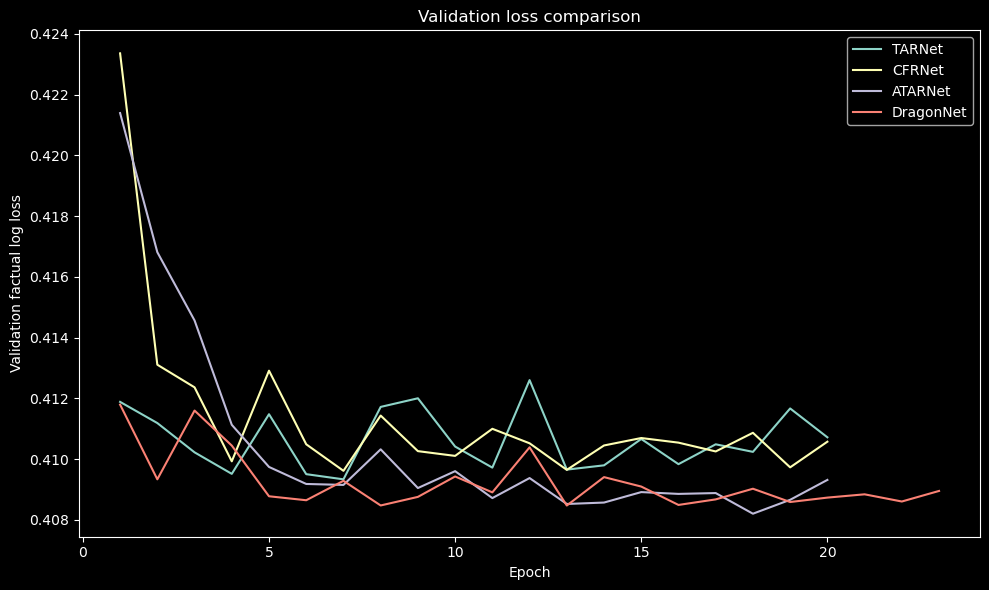

In [15]:
plt.figure(figsize=(10, 6))

for name, history in training_histories.items():
    plt.plot(
        history["epoch"],
        history["validation_factual_log_loss"],
        label=name,
    )

plt.xlabel("Epoch")
plt.ylabel("Validation factual log loss")
plt.title("Validation loss comparison")
plt.legend()
plt.tight_layout()
plt.show()


# Predict Test

In [16]:
def predict_model(
    model_name: str,
    model: nn.Module,
    loader: DataLoader,
) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    mu0_parts = []
    mu1_parts = []

    with torch.no_grad():
        for numeric, categorical, _, _ in loader:
            numeric = numeric.to(device)
            categorical = categorical.to(device)

            if model_name == "TARNet":
                logits = model(numeric, categorical)
                mu0 = torch.sigmoid(logits[:, 0])
                mu1 = torch.sigmoid(logits[:, 1])

            else:
                outputs = model(numeric, categorical)
                mu0 = torch.sigmoid(
                    outputs["control_logit"]
                )
                mu1 = torch.sigmoid(
                    outputs["treatment_logit"]
                )

            mu0_parts.append(mu0.cpu().numpy())
            mu1_parts.append(mu1.cpu().numpy())

    return (
        np.concatenate(mu0_parts),
        np.concatenate(mu1_parts),
    )


base_test_results = test_df.reset_index(drop=True)[
    [
        "original_row_index",
        treatment_column,
        outcome_column,
        *numerical_columns,
        *categorical_columns,
    ]
].copy()

prediction_tables = {}

for name, model in trained_models.items():
    _, _, model_test_loader = get_loaders(name)

    mu0, mu1 = predict_model(
        name,
        model,
        model_test_loader,
    )

    result = base_test_results.copy()
    result["predicted_mu0"] = mu0
    result["predicted_mu1"] = mu1
    result["predicted_uplift"] = mu1 - mu0
    result["model"] = name

    prediction_tables[name] = result

all_predictions = pd.concat(
    prediction_tables.values(),
    ignore_index=True,
)

display(all_predictions.head())


,original_row_index,treatment,visit,recency,history,mens,womens,history_segment,zip_code,newbie,channel,predicted_mu0,predicted_mu1,predicted_uplift,model
0,15132,1,1,6,508.62,0,1,5) $500 - $750,Surburban,1,Web,0.090973,0.182292,0.091319,TARNet
1,22478,1,0,10,460.26,1,1,4) $350 - $500,Urban,0,Phone,0.204388,0.275863,0.071475,TARNet
2,29758,1,0,10,35.05,1,0,1) $0 - $100,Surburban,0,Phone,0.086977,0.126542,0.039565,TARNet
3,57981,1,0,7,141.74,1,0,2) $100 - $200,Urban,0,Phone,0.099099,0.135197,0.036098,TARNet
4,41371,1,0,7,31.30,0,1,1) $0 - $100,Rural,1,Phone,0.057237,0.137974,0.080737,TARNet


In [17]:
logistic_control_mask = train_treatment_array == 0
logistic_treatment_mask = train_treatment_array == 1

control_logistic_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=CONFIG.split_seed,
)

treatment_logistic_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=CONFIG.split_seed,
)

started_at = time.perf_counter()

control_logistic_model.fit(
    X_train_logistic[logistic_control_mask],
    train_outcome_array[logistic_control_mask],
)

treatment_logistic_model.fit(
    X_train_logistic[logistic_treatment_mask],
    train_outcome_array[logistic_treatment_mask],
)

training_times["Logistic Regression"] = (
    time.perf_counter() - started_at
)

logistic_mu0 = control_logistic_model.predict_proba(
    X_test_logistic
)[:, 1]
logistic_mu1 = treatment_logistic_model.predict_proba(
    X_test_logistic
)[:, 1]

logistic_result = base_test_results.copy()
logistic_result["predicted_mu0"] = logistic_mu0
logistic_result["predicted_mu1"] = logistic_mu1
logistic_result["predicted_uplift"] = (
    logistic_result["predicted_mu1"]
    - logistic_result["predicted_mu0"]
)
logistic_result["model"] = "Logistic Regression"

prediction_tables["Logistic Regression"] = logistic_result

model_parameter_counts["Logistic Regression"] = int(
    control_logistic_model.coef_.size
    + control_logistic_model.intercept_.size
    + treatment_logistic_model.coef_.size
    + treatment_logistic_model.intercept_.size
)

all_predictions = pd.concat(
    prediction_tables.values(),
    ignore_index=True,
)

display(logistic_result.head())


,original_row_index,treatment,visit,recency,history,mens,womens,history_segment,zip_code,newbie,channel,predicted_mu0,predicted_mu1,predicted_uplift,model
0,15132,1,1,6,508.62,0,1,5) $500 - $750,Surburban,1,Web,0.084792,0.187335,0.102543,Logistic Regression
1,22478,1,0,10,460.26,1,1,4) $350 - $500,Urban,0,Phone,0.141162,0.231716,0.090555,Logistic Regression
2,29758,1,0,10,35.05,1,0,1) $0 - $100,Surburban,0,Phone,0.075687,0.120624,0.044937,Logistic Regression
3,57981,1,0,7,141.74,1,0,2) $100 - $200,Urban,0,Phone,0.082151,0.127749,0.045598,Logistic Regression
4,41371,1,0,7,31.30,0,1,1) $0 - $100,Rural,1,Phone,0.060476,0.131992,0.071516,Logistic Regression


# Evaluation funcs

In [18]:
def safe_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, y_score)


def qini_curve(frame: pd.DataFrame) -> pd.DataFrame:
    ranked = frame.sort_values(
        "predicted_uplift",
        ascending=False,
        kind="mergesort",
    ).reset_index(drop=True)

    treatment = ranked[treatment_column].to_numpy(
        dtype=float
    )
    outcome = ranked[outcome_column].to_numpy(
        dtype=float
    )

    propensity = treatment.mean()

    contribution = outcome * (
        treatment / propensity
        - (1 - treatment) / (1 - propensity)
    )

    cumulative_gain = np.concatenate([
        [0.0],
        np.cumsum(contribution) / len(ranked),
    ])

    fraction_targeted = np.linspace(
        0.0,
        1.0,
        len(cumulative_gain),
    )

    return pd.DataFrame({
        "fraction_targeted": fraction_targeted,
        "cumulative_gain": cumulative_gain,
        "random_gain": (
            fraction_targeted * cumulative_gain[-1]
        ),
    })


def qini_coefficient(curve: pd.DataFrame) -> float:
    return float(np.trapz(
        curve["cumulative_gain"]
        - curve["random_gain"],
        curve["fraction_targeted"],
    ))


def uplift_curve(frame: pd.DataFrame) -> pd.DataFrame:
    ranked = frame.sort_values(
        "predicted_uplift",
        ascending=False,
        kind="mergesort",
    ).reset_index(drop=True)

    treatment = ranked[treatment_column].to_numpy(
        dtype=float
    )
    outcome = ranked[outcome_column].to_numpy(
        dtype=float
    )

    treated_outcomes = np.cumsum(
        outcome * treatment
    )
    control_outcomes = np.cumsum(
        outcome * (1 - treatment)
    )

    treated_count = np.cumsum(treatment)
    control_count = np.cumsum(1 - treatment)

    treated_rate = np.divide(
        treated_outcomes,
        treated_count,
        out=np.zeros_like(treated_outcomes),
        where=treated_count > 0,
    )

    control_rate = np.divide(
        control_outcomes,
        control_count,
        out=np.zeros_like(control_outcomes),
        where=control_count > 0,
    )

    observed_uplift = treated_rate - control_rate

    return pd.DataFrame({
        "fraction_targeted": (
            np.arange(1, len(ranked) + 1)
            / len(ranked)
        ),
        "observed_uplift": observed_uplift,
    })


def auuc(curve: pd.DataFrame) -> float:
    x = np.concatenate([
        [0.0],
        curve["fraction_targeted"].to_numpy(),
    ])

    y = np.concatenate([
        [0.0],
        curve["observed_uplift"].to_numpy(),
    ])

    return float(np.trapz(y, x))


def evaluate_model(frame: pd.DataFrame):
    treatment = frame[treatment_column].to_numpy()
    outcome = frame[outcome_column].to_numpy()

    factual_probability = np.where(
        treatment == 1,
        frame["predicted_mu1"],
        frame["predicted_mu0"],
    )

    qini = qini_curve(frame)
    uplift = uplift_curve(frame)

    metrics = {
        "factual_log_loss": log_loss(
            outcome,
            np.clip(
                factual_probability,
                1e-6,
                1 - 1e-6,
            ),
        ),
        "factual_roc_auc": safe_roc_auc(
            outcome,
            factual_probability,
        ),
        "mean_predicted_mu0": (
            frame["predicted_mu0"].mean()
        ),
        "mean_predicted_mu1": (
            frame["predicted_mu1"].mean()
        ),
        "mean_predicted_uplift": (
            frame["predicted_uplift"].mean()
        ),
        "uplift_standard_deviation": (
            frame["predicted_uplift"].std()
        ),
        "qini_coefficient": qini_coefficient(qini),
        "auuc": auuc(uplift),
    }

    return metrics, qini, uplift


In [19]:
evaluation_rows = []
qini_curves = {}
uplift_curves = {}

for name, table in prediction_tables.items():
    metrics, qini, uplift = evaluate_model(table)

    metrics["model"] = name
    metrics["trainable_parameters"] = int(
        model_parameter_counts[name]
    )

    evaluation_rows.append(metrics)
    qini_curves[name] = qini
    uplift_curves[name] = uplift

evaluation_table = (
    pd.DataFrame(evaluation_rows)
    .set_index("model")
    .sort_values(
        "qini_coefficient",
        ascending=False,
    )
)

display(evaluation_table)

print("Zooming on required Metrics")
display(evaluation_table[["auuc", "qini_coefficient"]])

,factual_log_loss,factual_roc_auc,mean_predicted_mu0,mean_predicted_mu1,mean_predicted_uplift,uplift_standard_deviation,qini_coefficient,auuc,trainable_parameters
model,,,,,,,,,
ATARNet,0.400768,0.645468,0.111093,0.171659,0.060566,0.024057,0.004447,0.073026,3748
Logistic Regression,0.401096,0.643776,0.105326,0.165313,0.059987,0.022425,0.004282,0.071794,40
TARNet,0.401614,0.641985,0.115372,0.173621,0.058249,0.018853,0.003271,0.070636,147838
CFRNet,0.401804,0.642249,0.112114,0.172973,0.060859,0.009372,0.002341,0.067069,147838
DragonNet,0.401492,0.642170,0.106319,0.167499,0.061180,0.015583,0.001774,0.062072,33856


Zooming on required Metrics


,auuc,qini_coefficient
model,,
ATARNet,0.073026,0.004447
Logistic Regression,0.071794,0.004282
TARNet,0.070636,0.003271
CFRNet,0.067069,0.002341
DragonNet,0.062072,0.001774


# Plots

## Qini Curves

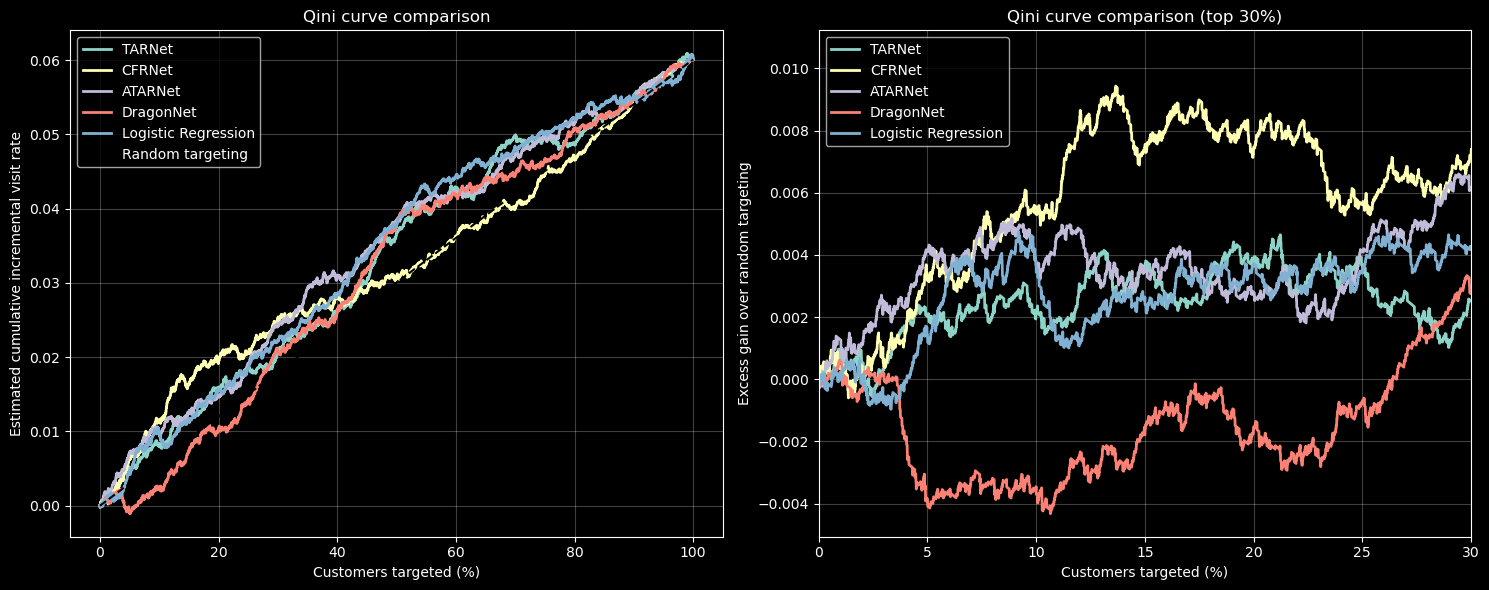

In [20]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    sharey=False,
)

reference_curve = qini_curves[
    next(iter(qini_curves))
]

for name, curve in qini_curves.items():
    x = curve["fraction_targeted"] * 100
    y = curve["cumulative_gain"]
    excess = curve["cumulative_gain"] - curve["random_gain"]

    axes[0].plot(x, y, linewidth=2, label=name)
    axes[1].plot(x, excess, linewidth=2, label=name)

axes[0].plot(
    reference_curve["fraction_targeted"] * 100,
    reference_curve["random_gain"],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random targeting",
)

axes[0].set_xlabel("Customers targeted (%)")
axes[0].set_ylabel(
    "Estimated cumulative incremental visit rate"
)
axes[0].set_title("Qini curve comparison")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].set_xlim(0, 30)
axes[1].set_xlabel("Customers targeted (%)")
axes[1].set_ylabel("Excess gain over random targeting")
axes[1].set_title("Qini curve comparison (top 30%)")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


## Uplift Curves

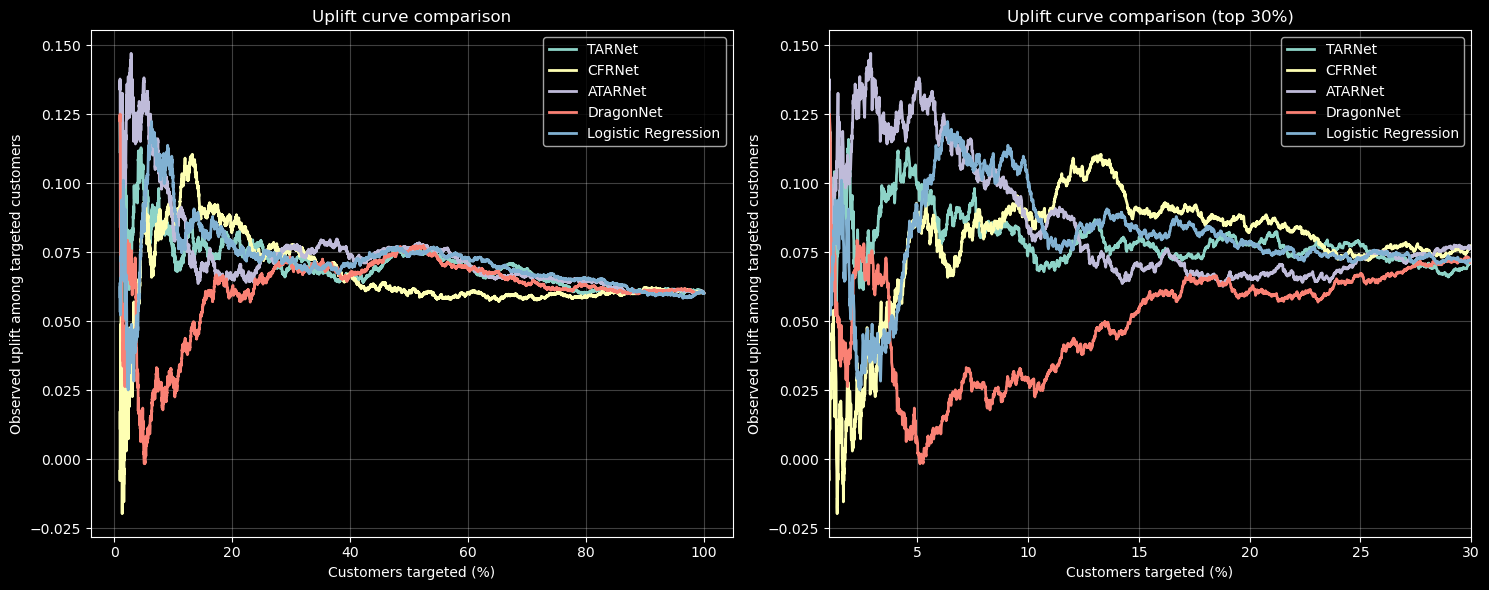

In [21]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    sharey=False,
)

for name, curve in uplift_curves.items():
    curve = curve.copy()
    curve = curve[curve["fraction_targeted"] >= 0.01]
    x = curve["fraction_targeted"] * 100
    y = curve["observed_uplift"]

    axes[0].plot(x, y, linewidth=2, label=name)

    zoomed = curve[curve["fraction_targeted"] <= 0.30]
    axes[1].plot(
        zoomed["fraction_targeted"] * 100,
        zoomed["observed_uplift"],
        linewidth=2,
        label=name,
    )

axes[0].set_xlabel("Customers targeted (%)")
axes[0].set_ylabel("Observed uplift among targeted customers")
axes[0].set_title("Uplift curve comparison")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].set_xlim(1, 30)
axes[1].set_xlabel("Customers targeted (%)")
axes[1].set_ylabel("Observed uplift among targeted customers")
axes[1].set_title("Uplift curve comparison (top 30%)")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


# Targeting Depth

In [22]:
def targeting_summary(
    frame: pd.DataFrame,
    fractions: Iterable[float],
) -> pd.DataFrame:
    ranked = frame.sort_values(
        "predicted_uplift",
        ascending=False,
        kind="mergesort",
    ).reset_index(drop=True)

    rows = []

    for fraction in fractions:
        count = max(
            1,
            int(round(len(ranked) * fraction)),
        )

        selected = ranked.iloc[:count]
        treated = selected[
            selected[treatment_column] == 1
        ]
        control = selected[
            selected[treatment_column] == 0
        ]

        treated_rate = treated[
            outcome_column
        ].mean()

        control_rate = control[
            outcome_column
        ].mean()

        observed_uplift = (
            treated_rate - control_rate
        )

        rows.append({
            "fraction_targeted": fraction,
            "customers_targeted": count,
            "treated_visit_rate": treated_rate,
            "control_visit_rate": control_rate,
            "observed_uplift": observed_uplift,
            "estimated_incremental_visits": (
                observed_uplift * count
            ),
        })

    return pd.DataFrame(rows)


targeting_tables = []

for name, table in prediction_tables.items():
    summary = targeting_summary(
        table,
        CONFIG.targeting_fractions,
    )
    summary["model"] = name
    targeting_tables.append(summary)

targeting_comparison = pd.concat(
    targeting_tables,
    ignore_index=True,
)

display(targeting_comparison)


,fraction_targeted,customers_targeted,treated_visit_rate,control_visit_rate,observed_uplift,estimated_incremental_visits,model
0,0.05,640,0.217290,0.117925,0.099365,63.593722,TARNet
1,0.10,1280,0.203468,0.127711,0.075757,96.969427,TARNet
2,0.20,2560,0.193925,0.115566,0.078359,200.599542,TARNet
3,0.30,3840,0.185535,0.114198,0.071337,273.934312,TARNet
4,0.50,6400,0.184427,0.109353,0.075074,480.473639,TARNet
5,1.00,12800,0.167584,0.107487,0.060098,769.248265,TARNet
6,0.05,640,0.314732,0.229167,0.085565,54.761905,CFRNet
7,0.10,1280,0.294582,0.205584,0.088999,113.918255,CFRNet
8,0.20,2560,0.267468,0.184275,0.083193,212.974887,CFRNet
9,0.30,3840,0.247204,0.170008,0.077196,296.432608,CFRNet


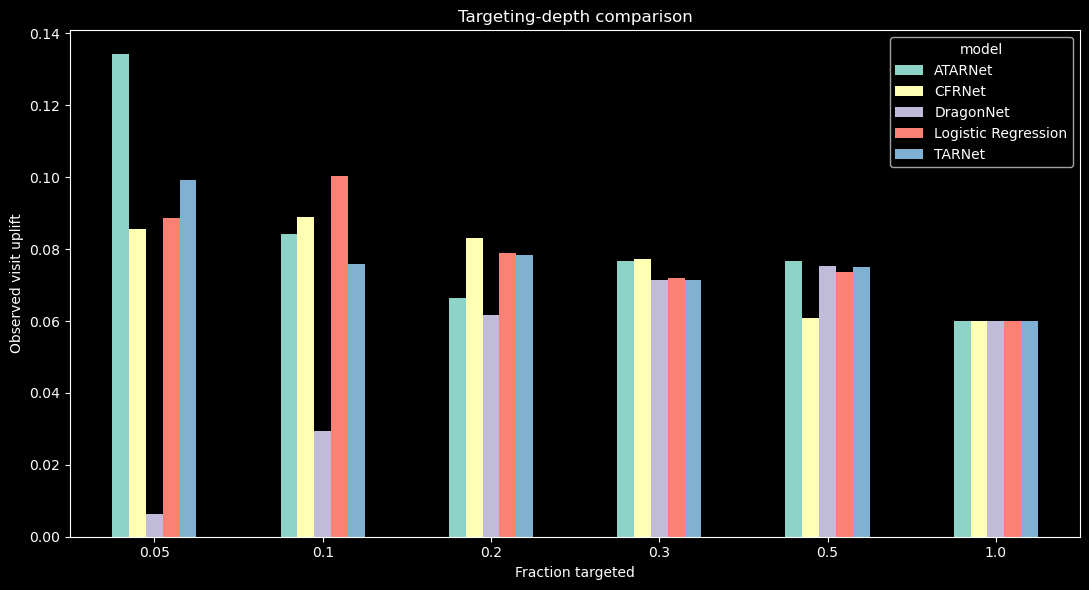

In [23]:
targeting_pivot = targeting_comparison.pivot(
    index="fraction_targeted",
    columns="model",
    values="observed_uplift",
)

targeting_pivot.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.xlabel("Fraction targeted")
plt.ylabel("Observed visit uplift")
plt.title("Targeting-depth comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Model Inter Corrs

In [24]:
uplift_matrix = pd.DataFrame({
    name: table["predicted_uplift"].to_numpy()
    for name, table in prediction_tables.items()
})

print("Correlation")
display(uplift_matrix.corr(method="pearson"))

Correlation


,TARNet,CFRNet,ATARNet,DragonNet,Logistic Regression
TARNet,1.000000,0.281745,0.861805,0.871269,0.803570
CFRNet,0.281745,1.000000,0.389922,0.467935,0.293711
ATARNet,0.861805,0.389922,1.000000,0.817140,0.871061
DragonNet,0.871269,0.467935,0.817140,1.000000,0.760406
Logistic Regression,0.803570,0.293711,0.871061,0.760406,1.000000
